# Absolute two-body motion: numerical vs. analytical (Kepler) propagation, and the J2 perturbation

This notebook exercises the inertial-frame dynamics layer of `ios_mission_planner`:

- `dynamics.orbital.two_body` — the two-body equations of motion $\ddot{\mathbf r} = -\mu \mathbf r / |\mathbf r|^3$, for numerical integration.
- `dynamics.orbital.kepler_propagator` — the closed-form analytical propagation of the same (unperturbed) two-body motion, via classical orbital elements and Kepler's equation.
- `dynamics.orbital.perturbations` — the two-body dynamics with the J2 (Earth oblateness) perturbation added.

Two things are checked here:

1. **Case A** — that the numerical integrator and the analytical Kepler propagator agree with each other on unperturbed motion (a correctness check on the implementation, in the same spirit as `cw_comparison.ipynb`).
2. **Case B** — how a real perturbation (J2) makes the orbit *actually* deviate from the unperturbed Keplerian solution over time — in particular the well-known secular regression of the ascending node — and that the numerical J2 propagation matches the known analytical secular rate.


In [1]:
from ios_mission_planner.constants import MU_EARTH, R_EARTH, J2_EARTH
from ios_mission_planner.dynamics.orbital.two_body import two_body_dynamics
from ios_mission_planner.dynamics.orbital.perturbations import two_body_j2_dynamics
from ios_mission_planner.dynamics.orbital.elements import (
    OrbitalElements, elements_to_state_vector, state_vector_to_elements,
)
from ios_mission_planner.dynamics.orbital.kepler_propagator import propagate_kepler
from ios_mission_planner.propagation.propagator import propagate

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.grid": True, "grid.alpha": 0.3, "axes.axisbelow": True,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
})

COL_ANA = "#1f77b4"   # analytical Kepler propagation
COL_NUM = "#d62728"   # numerical integration (two-body, unperturbed)
COL_J2 = "#9467bd"    # numerical integration (two-body + J2)
COL_EARTH = "#7f7f7f"


## Reference orbit

An inclined, eccentric LEO orbit — general enough to be a meaningful test (a purely circular/equatorial orbit would hit the RAAN/argument-of-periapsis singularity noted in `elements.py`).

In [2]:
elements0 = OrbitalElements(
    a=7000.0,                  # km
    e=0.05,
    i=np.radians(51.6),        # deg -> rad, ISS-like inclination
    raan=np.radians(30.0),
    argp=np.radians(60.0),
    nu=np.radians(15.0),
)
state0 = elements_to_state_vector(elements0, MU_EARTH)

n = np.sqrt(MU_EARTH / elements0.a**3)
T = 2 * np.pi / n

print(f"state0 = {state0}")
print(f"n = {n:.6e} rad/s")
print(f"T = {T:.1f} s  ({T/60:.2f} min)")


state0 = [-5.05205434e+02  4.32292925e+03  5.04216315e+03 -7.26962666e+00
 -2.65907515e+00  1.68054897e+00]
n = 1.078008e-03 rad/s
T = 5828.5 s  (97.14 min)


## Wrapper functions

`propagate_numerical(...)` integrates `two_body_dynamics` (or `two_body_j2_dynamics`) with `propagate(...)`, at tight tolerances (`DOP853`, `rtol=atol=1e-12`) so any disagreement with the analytical solution reflects the dynamics, not integration error.

`propagate_analytical(...)` evaluates `propagate_kepler` independently at each requested time (it has no notion of a trajectory — every call is a fresh closed-form propagation from `state0`).

In [3]:
def propagate_numerical(dynamics, state0, t_eval, **kwargs):
    solution = propagate(dynamics, state0, (t_eval[0], t_eval[-1]), t_eval,
                          method="DOP853", rtol=1e-12, atol=1e-12, **kwargs)
    return solution.y.T


def propagate_analytical(state0, t_eval, mu):
    return np.array([propagate_kepler(state0, t, mu) for t in t_eval])


## Case A — unperturbed two-body: numerical vs. analytical

Both methods propagate the *same* unperturbed two-body dynamics; they should agree down to numerical noise.

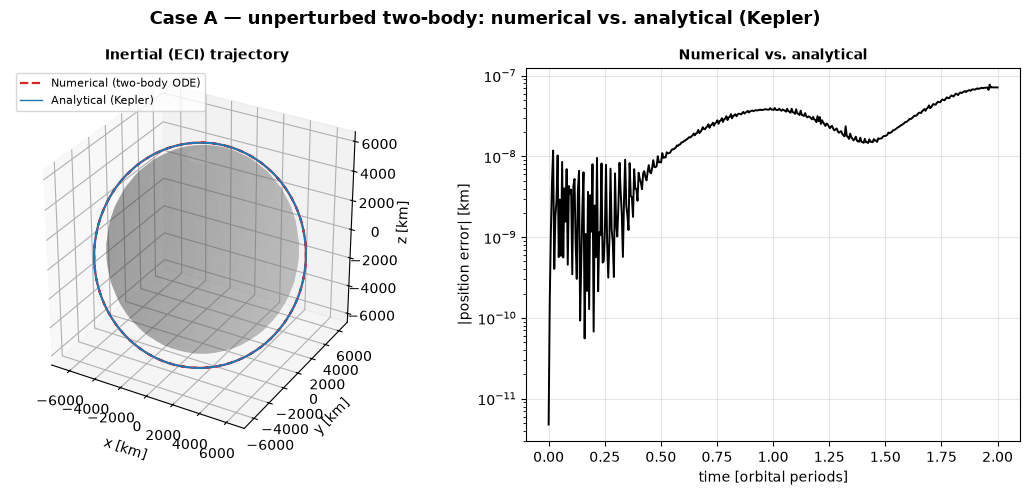

max position error: 7.726e-08 km


In [4]:
t_eval_a = np.linspace(0, 2 * T, 400)

num_a = propagate_numerical(two_body_dynamics, state0, t_eval_a, mu=MU_EARTH)
ana_a = propagate_analytical(state0, t_eval_a, MU_EARTH)
err_a = np.linalg.norm(num_a[:, :3] - ana_a[:, :3], axis=1)

fig = plt.figure(figsize=(11, 5))
fig.suptitle("Case A — unperturbed two-body: numerical vs. analytical (Kepler)", fontsize=13, fontweight="bold")

ax3d = fig.add_subplot(1, 2, 1, projection="3d")
ax3d.plot(num_a[:, 0], num_a[:, 1], num_a[:, 2], color=COL_NUM, lw=1.6, ls="--", label="Numerical (two-body ODE)")
ax3d.plot(ana_a[:, 0], ana_a[:, 1], ana_a[:, 2], color=COL_ANA, lw=1.0, label="Analytical (Kepler)")

u, v = np.meshgrid(np.linspace(0, 2 * np.pi, 40), np.linspace(0, np.pi, 20))
xe = R_EARTH * np.cos(u) * np.sin(v)
ye = R_EARTH * np.sin(u) * np.sin(v)
ze = R_EARTH * np.cos(v)
ax3d.plot_surface(xe, ye, ze, color=COL_EARTH, alpha=0.25, linewidth=0)

ax3d.set_xlabel("x [km]"); ax3d.set_ylabel("y [km]"); ax3d.set_zlabel("z [km]")
ax3d.set_title("Inertial (ECI) trajectory", fontsize=10)
ax3d.legend(loc="upper left", fontsize=8)
ax3d.set_box_aspect([1, 1, 1])

ax_err = fig.add_subplot(1, 2, 2)
ax_err.semilogy(t_eval_a / T, np.clip(err_a, 1e-14, None), color="k", lw=1.4)
ax_err.set_xlabel("time [orbital periods]"); ax_err.set_ylabel("|position error| [km]")
ax_err.set_title("Numerical vs. analytical", fontsize=10)

plt.tight_layout()
plt.show()
print(f"max position error: {err_a.max():.3e} km")


## Case B — J2 perturbation: secular node regression

Now the numerical propagation includes the J2 (oblateness) term, while the analytical propagation still assumes pure Keplerian motion — so any growing disagreement between them is *real physics*, not numerical error.

The best-known secular effect of J2 is the regression of the ascending node, at rate:

$$
\dot\Omega = -\frac{3}{2} n J_2 \left(\frac{R_\oplus}{p}\right)^2 \cos i, \qquad p = a(1-e^2)
$$

We propagate over many orbits, extract $\Omega(t)$ from the numerical trajectory at each sample, and compare its secular slope to this formula.

numerical RAAN drift rate:  -9.165327e-07 rad/s
analytical secular rate:    -9.127755e-07 rad/s
relative difference:        0.4116%


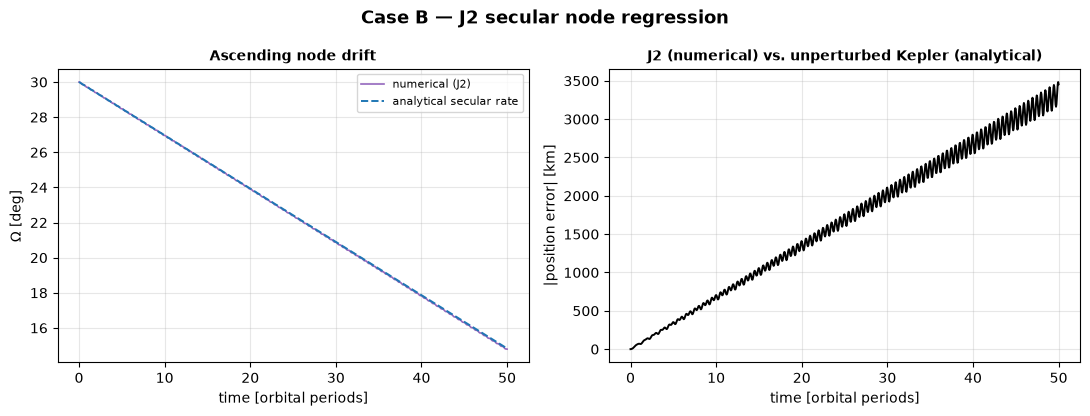

In [5]:
elements0_b = OrbitalElements(
    a=6978.0,               # km, ~600 km altitude
    e=0.001,
    i=np.radians(51.6),
    raan=np.radians(30.0),
    argp=0.0,
    nu=0.0,
)
state0_b = elements_to_state_vector(elements0_b, MU_EARTH)
n_b = np.sqrt(MU_EARTH / elements0_b.a**3)
T_b = 2 * np.pi / n_b

n_orbits = 50
t_eval_b = np.linspace(0, n_orbits * T_b, n_orbits * 20)

num_b_j2 = propagate_numerical(two_body_j2_dynamics, state0_b, t_eval_b,
                                mu=MU_EARTH, j2=J2_EARTH, r_eq=R_EARTH)
ana_b = propagate_analytical(state0_b, t_eval_b, MU_EARTH)
err_b = np.linalg.norm(num_b_j2[:, :3] - ana_b[:, :3], axis=1)

raan_t = np.unwrap([state_vector_to_elements(s, MU_EARTH).raan for s in num_b_j2])
raan_rate_numeric, raan0_fit = np.polyfit(t_eval_b, raan_t, 1)

p_b = elements0_b.a * (1.0 - elements0_b.e**2)
raan_rate_analytic = -1.5 * n_b * J2_EARTH * (R_EARTH / p_b) ** 2 * np.cos(elements0_b.i)

print(f"numerical RAAN drift rate:  {raan_rate_numeric: .6e} rad/s")
print(f"analytical secular rate:    {raan_rate_analytic: .6e} rad/s")
print(f"relative difference:        {abs(raan_rate_numeric - raan_rate_analytic) / abs(raan_rate_analytic):.4%}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
fig.suptitle("Case B — J2 secular node regression", fontsize=13, fontweight="bold")

t_orbits = t_eval_b / T_b
axes[0].plot(t_orbits, np.degrees(raan_t), color=COL_J2, lw=1.2, label="numerical (J2)")
axes[0].plot(t_orbits, np.degrees(raan0_fit + raan_rate_analytic * t_eval_b), color=COL_ANA,
             lw=1.4, ls="--", label="analytical secular rate")
axes[0].set_xlabel("time [orbital periods]"); axes[0].set_ylabel(r"$\Omega$ [deg]")
axes[0].set_title("Ascending node drift", fontsize=10)
axes[0].legend(fontsize=8)

axes[1].plot(t_orbits, err_b, color="k", lw=1.4)
axes[1].set_xlabel("time [orbital periods]"); axes[1].set_ylabel("|position error| [km]")
axes[1].set_title("J2 (numerical) vs. unperturbed Kepler (analytical)", fontsize=10)

plt.tight_layout()
plt.show()


## Summary

- **Case A** confirms `two_body_dynamics` (numerical) and `propagate_kepler` (analytical) describe the same unperturbed motion: their disagreement stays at the level of the integrator's own numerical noise.
- **Case B** shows the two propagators diverge once J2 is included in the numerical one — and that the divergence is not a bug but the expected physics: the numerically observed nodal regression rate matches the classical J2 secular formula to within a fraction of a percent (the small residual is the short-period J2 oscillation superimposed on the secular drift, which the numerical trajectory captures and the pure-Keplerian analytical one does not).
- Practical takeaway for the rest of the planner: use `propagate_kepler` where perturbations don't matter and repeated fast evaluations do (e.g. inside a maneuver-targeting optimization loop); switch to numerical propagation with `two_body_j2_dynamics` whenever J2 (or other perturbations) needs to be captured.